In [23]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd


 # Assignment Rosenbrock function

In [2]:
def calculate_objective_1(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

In [3]:
def compute_gradient_1(x):
    df_dx1 = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    df_dx2 = 200 * (x[1] - x[0]**2)
    return np.array([df_dx1, df_dx2])

In [4]:
def gradient_descent_1(x0, gamma, max_iter=10000, tol=1e-4):
    x = x0.copy()
    history = [calculate_objective_1(x)]
    n_iter = max_iter

    start = time.time()
    for i in range(max_iter):
        grad = compute_gradient_1(x)
        if np.any(np.isnan(grad)) or np.any(np.isinf(grad)):
            print(f"  Diverged at iteration {i} (overflow)")
            n_iter = i
            break
        if np.linalg.norm(grad) < tol:
            print(f"  Converged at iteration {i+1}")
            n_iter = i + 1
            break
        x = x - gamma * grad
        val = calculate_objective_1(x)
        if np.isnan(val) or np.isinf(val):
            print(f"  Diverged at iteration {i} (NaN/Inf)")
            n_iter = i
            break
        history.append(val)
    else:
        print(f"  Max iterations reached ({max_iter})")

    elapsed = time.time() - start
    return x, history, n_iter, elapsed

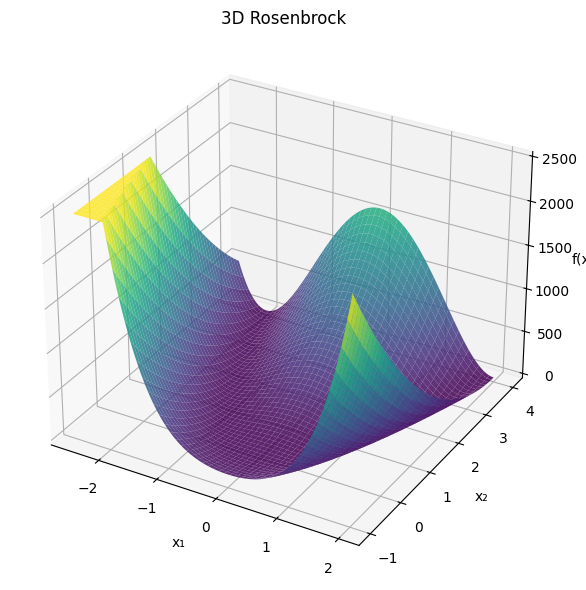

In [11]:
x1 = np.linspace(-2.5, 2, 300)
x2 = np.linspace(-1, 4, 300)
X1, X2 = np.meshgrid(x1, x2)
F = 100 * (X2 - X1**2)**2 + (1 - X1)**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

F_clipped = np.clip(F, 0, 2500)
ax.plot_surface(X1, X2, F_clipped, cmap='viridis', alpha=0.85)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_zlabel('f(x)')
ax.set_title('3D Rosenbrock')

plt.tight_layout()
plt.show()

In [5]:
x0 = np.array([-2.0, 2.0])
gammas = [0.1, 0.01, 0.001]
results_1 = {}

for gamma in gammas:
    print(f"\nStep size γ = {gamma}")
    x_sol, history, n_iter, t = gradient_descent_1(x0, gamma)
    results_1[gamma] = history
    print(f"  Iterations: {n_iter}")
    print(f"  Time: {t:.4f} sec")
    if not np.any(np.isnan(x_sol)):
        print(f"  Solution: x = {x_sol}")
        print(f"  f(x*) = {history[-1]:.6f}")


Step size γ = 0.1
  Diverged at iteration 3 (NaN/Inf)
  Iterations: 3
  Time: 0.0009 sec
  Solution: x = [-1.69211905e+80  5.23131186e+53]
  f(x*) = 68416559506579533735447896375144265028038229863443650236028991561031566412297605569105134428923844062347264.000000

Step size γ = 0.01
  Diverged at iteration 4 (NaN/Inf)
  Iterations: 4
  Time: 0.0012 sec
  Solution: x = [4.92907187e+116 4.95260208e+077]
  f(x*) = 6132066833127449879852774600993751617769000481590917948780077768876443881668429780424524629519115449720113474325192825099001836178501649219665196383037554688.000000

Step size γ = 0.001


/tmp/ipykernel_2963/2964431310.py:2: RuntimeWarning: overflow encountered in scalar power
  return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2


  Max iterations reached (10000)
  Iterations: 10000
  Time: 0.3835 sec
  Solution: x = [0.99117313 0.98238866]
  f(x*) = 0.000078


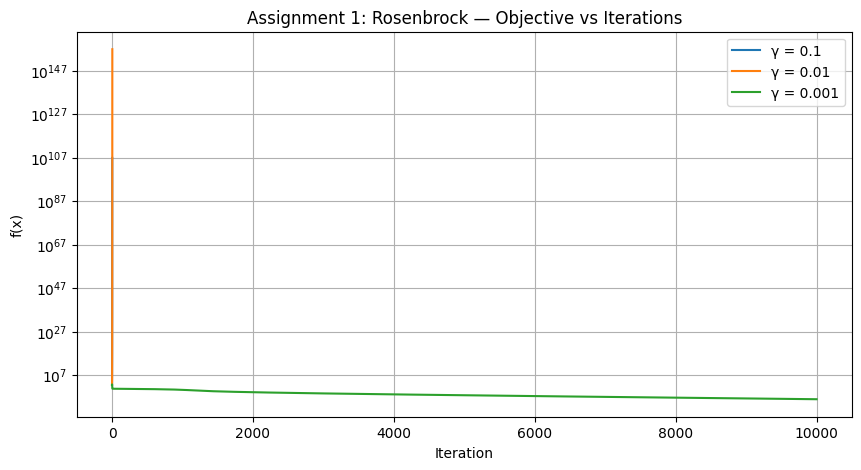

In [6]:
plt.figure(figsize=(10, 5))
for gamma in gammas:
    h = results_1[gamma]
    if len(h) > 1:
        plt.plot(h, label=f'γ = {gamma}')
plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title('Assignment 1: Rosenbrock- Objective vs Iterations')
plt.legend()
plt.yscale('log')
plt.grid(True)


For γ = 0.1 and γ = 0.01, the algorithm blows up almost immediately at iteration 3 and 4, respectively. This happens because the gradient at the starting point (−2, 2) is very large, and a big step size overshoots that much that the values hit overflow within a few iterations.

γ = 0.001 is small enough to stay stable, but 10000 iterations still weren't enough to satisfy the stopping criterion. The function(Rosenbrock) has a narrow curved valley where the curvature along the valley and across it differ by orders of magnitude. Gradient descent ends up zigzagging between the walls instead of following the valley toward (1, 1), which makes progress slow.

The solution found, x∗≈(0.991, 0.982) is reasonably close to the true minimum at (1, 1) where f = 0,

# Assignment Least Squares Estimation

In [13]:
def calculate_objective_2(x, A, b):
    m = len(b)
    r = A @ x - b
    return (1 / (2 * m)) * np.dot(r, r)

In [17]:
def compute_gradient_2(x, A, b):
    m = len(b)
    return (1 / m) * A.T @ (A @ x - b)

In [18]:
def gradient_descent_2(x0, A, b, gamma, max_iter=50):
    x = x0.copy()
    history = [calculate_objective_2(x, A, b)]
    start = time.time()
    for i in range(max_iter):
        grad = compute_gradient_2(x, A, b)
        x = x - gamma * grad
        history.append(calculate_objective_2(x, A, b))
    elapsed = time.time() - start
    return x, history, elapsed

In [25]:

np.random.seed(42)
m, n = 100, 10
A = np.random.randn(m, n)
b = np.random.randn(m)
x0_2 = np.zeros(n)



In [26]:
print("Matrix A (first 10):")
display(pd.DataFrame(A, columns=[f'x{i+1}' for i in range(n)]).round(3).head(10))

print("Мусещк b:")
display(pd.DataFrame(b, columns=['b']).round(3).head(10))

Matrix A (first 10):


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,0.497,-0.138,0.648,1.523,-0.234,-0.234,1.579,0.767,-0.469,0.543
1,-0.463,-0.466,0.242,-1.913,-1.725,-0.562,-1.013,0.314,-0.908,-1.412
2,1.466,-0.226,0.068,-1.425,-0.544,0.111,-1.151,0.376,-0.601,-0.292
3,-0.602,1.852,-0.013,-1.058,0.823,-1.221,0.209,-1.960,-1.328,0.197
4,0.738,0.171,-0.116,-0.301,-1.479,-0.720,-0.461,1.057,0.344,-1.763
5,0.324,-0.385,-0.677,0.612,1.031,0.931,-0.839,-0.309,0.331,0.976
6,-0.479,-0.186,-1.106,-1.196,0.813,1.356,-0.072,1.004,0.362,-0.645
7,0.361,1.538,-0.036,1.565,-2.620,0.822,0.087,-0.299,0.092,-1.988
8,-0.220,0.357,1.478,-0.518,-0.808,-0.502,0.915,0.329,-0.530,0.513
9,0.097,0.969,-0.702,-0.328,-0.392,-1.464,0.296,0.261,0.005,-0.235


Мусещк b:


,b
0,1.399
1,0.925
2,0.060
3,-0.647
4,0.698
5,0.393
6,0.895
7,0.635
8,1.050
9,-0.535


In [27]:

beta = (1 / m) * np.linalg.norm(A, 2)**2
print(f"\nSmoothness constant β = {beta:.4f}  →  1/β = {1/beta:.4f}")

x_norm_bound = 20.0
L = (1/m) * (np.linalg.norm(A.T @ A, 2) * x_norm_bound + np.linalg.norm(A.T @ b))
print(f"Lipschitz constant   L = {L:.4f}  →  1/L = {1/L:.4f}")

gammas_2 = {'γ=0.1': 0.1, 'γ=1/β': 1/beta, 'γ=1/L': 1/L}
results_2 = {}

for label, gamma in gammas_2.items():
    x_sol, history, t = gradient_descent_2(x0_2, A, b, gamma)
    results_2[label] = history
    print(f"\n{label} (γ = {gamma:.6f})")
    print(f"  Time for 50 iterations: {t:.5f} sec")
    print(f"  Final f(x) = {history[-1]:.6f}")



Smoothness constant β = 1.5614  →  1/β = 0.6404
Lipschitz constant   L = 31.4670  →  1/L = 0.0318

γ=0.1 (γ = 0.100000)
  Time for 50 iterations: 0.00388 sec
  Final f(x) = 0.427710

γ=1/β (γ = 0.640445)
  Time for 50 iterations: 0.00086 sec
  Final f(x) = 0.427682

γ=1/L (γ = 0.031779)
  Time for 50 iterations: 0.00153 sec
  Final f(x) = 0.430175


The most interesting thing here is that γ = 1/L performs the worst despite being derived from a Lipschitz bound - it reaches the highest final value after 50 iterations.  L = 31.47 is much larger than β = 1.56, so 1/L = 0.032 is an extremely conservative step. The algorithm is technically good, but moves so slowly that 50 iterations barely scratch the surface.

γ = 1/β wins both on speed and final value. β is the smoothness constant of the objective itself, so 1/β is the theoretically optimal step for this specific problem — large enough to make real progress, small enough not to overshoot.

γ = 0.1 lands almost exactly at the same final value as 1/β (0.4277 vs 0.4277), but take longer. It happened to be a decent step size for this particular matrix, though there's no theoretical guarantee it would work as well on a different A.


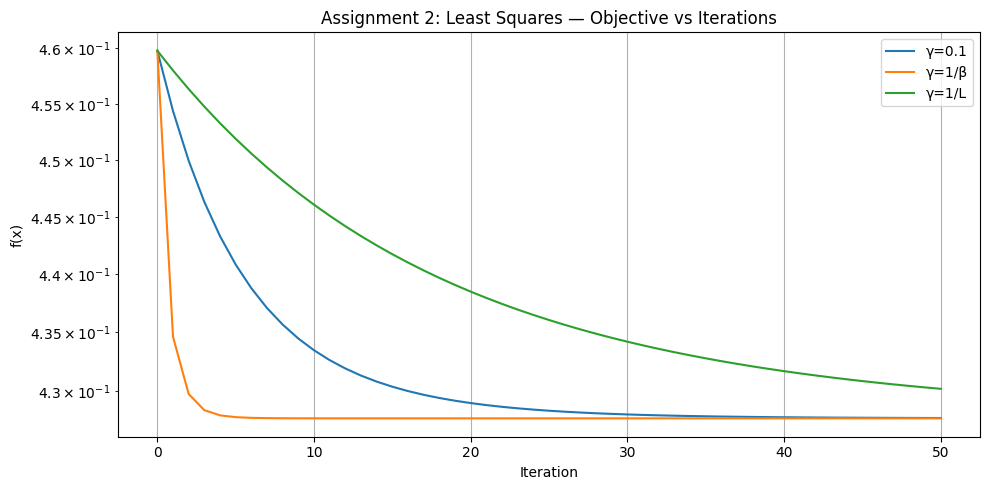

In [20]:

plt.figure(figsize=(10, 5))
for label, history in results_2.items():
    plt.plot(history, label=label)
plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title('Assignment 2: Least Squares - Objective vs Iterations')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()



 # Assignment 3 Fixed Point Problems.

In [28]:
def calculate_objective_3a(x):
    return 0.5 * (x - np.log(1 + x))**2

In [29]:
def calculate_objective_3b(x):
    return 0.5 * (x - np.log(2 + x))**2

In [30]:
def compute_gradient_3a(x):
    return (x - np.log(1 + x)) * (1 - 1 / (1 + x))

In [31]:
def compute_gradient_3b(x):
    return (x - np.log(2 + x)) * (1 - 1 / (2 + x))

In [32]:
def gradient_descent_3(x0, calc_obj, calc_grad, gamma, max_iter=100):
    x = float(x0)
    history_f = [calc_obj(x)]
    history_x = [x]
    start = time.time()
    for i in range(max_iter):
        grad = calc_grad(x)
        x = x - gamma * grad
        history_f.append(calc_obj(x))
        history_x.append(x)
    elapsed = time.time() - start
    return x, history_f, history_x, elapsed



Approximate fixed points:
  ln(1+x) = x  →  x* = 0
  ln(2+x) = x  →  x* ≈ 1.1462


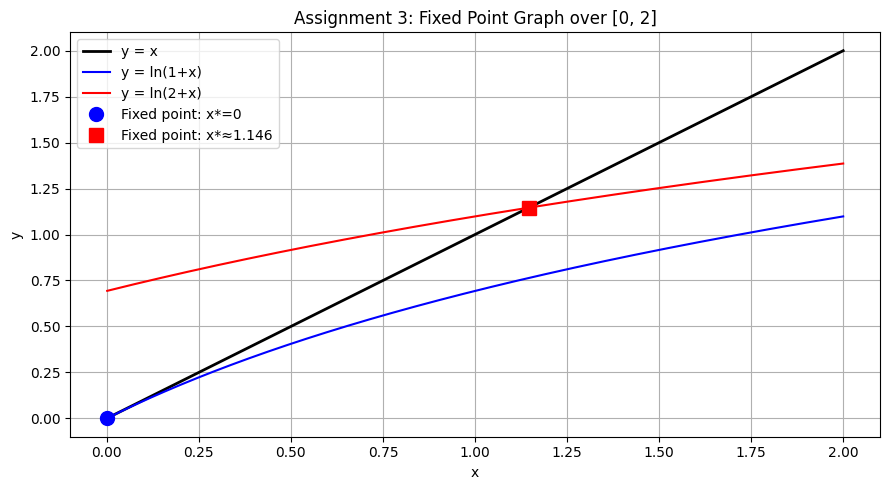

In [33]:

# Plot fixed points graph
x_plot = np.linspace(0.001, 2, 500)
plt.figure(figsize=(9, 5))
plt.plot(x_plot, x_plot, 'k-', label='y = x', linewidth=2)
plt.plot(x_plot, np.log(1 + x_plot), 'b-', label='y = ln(1+x)')
plt.plot(x_plot, np.log(2 + x_plot), 'r-', label='y = ln(2+x)')
# ln(1+x)=x only at x=0
plt.plot(0, 0, 'bo', markersize=10, label='Fixed point: x*=0')
# ln(2+x)=x approximately at x≈1.256
from scipy.optimize import brentq
fp2 = brentq(lambda x: x - np.log(2 + x), 0.5, 2)
plt.plot(fp2, fp2, 'rs', markersize=10, label=f'Fixed point: x*≈{fp2:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Assignment 3: Fixed Point Graph over [0, 2]')
plt.legend()
plt.grid(True)
plt.tight_layout()


print(f"\nApproximate fixed points:")
print(f"  ln(1+x) = x  →  x* = 0")
print(f"  ln(2+x) = x  →  x* ≈ {fp2:.4f}")

In [36]:

# Compute Lipschitz constants numerically
xs = np.linspace(0.001, 2, 10000)
h = 1e-6
L1 = np.max(np.abs((compute_gradient_3a(xs + h) - compute_gradient_3a(xs - h)) / (2 * h)))
L2 = np.max(np.abs((compute_gradient_3b(xs + h) - compute_gradient_3b(xs - h)) / (2 * h)))

print(f"\nLipschitz constant L1 = {L1:.4f}  →  γ1 = 1/L1 = {1/L1:.4f}")
print(f"Lipschitz constant L2 = {L2:.4f}  →  γ2 = 1/L2 = {1/L2:.4f}")

# Run g1
print("\n--- g1 with γ = 1/L1 ---")
x_sol1, hist_f1, hist_x1, t1 = gradient_descent_3(0.5, calculate_objective_3a, compute_gradient_3a, 1/L1)
print(f"Time: {t1:.5f} sec")
print(f"{'Iter':>6} | {'x':>12} | {'g1(x)':>16}")
for i in range(0, 100, 10):
    print(f"{i:>6} | {hist_x1[i]:>12.6f} | {hist_f1[i]:>16.10f}")
print(f"Converges to 0? {'YES ✓' if hist_f1[-1] < 1e-8 else f'No, f={hist_f1[-1]:.2e}'}")

# Run g2
print("\n--- g2 with γ = 1/L2 ---")
x_sol2, hist_f2, hist_x2, t2 = gradient_descent_3(0.5, calculate_objective_3b, compute_gradient_3b, 1/L2)
print(f"Time: {t2:.5f} sec")
print(f"{'Iter':>6} | {'x':>12} | {'g2(x)':>16}")
for i in range(0, 100, 10):
    print(f"{i:>6} | {hist_x2[i]:>12.6f} | {hist_f2[i]:>16.10f}")



Lipschitz constant L1 = 0.5446  →  γ1 = 1/L1 = 1.8362
Lipschitz constant L2 = 0.6009  →  γ2 = 1/L2 = 1.6643

--- g1 with γ = 1/L1 ---
Time: 0.00086 sec
  Iter |            x |            g1(x)
     0 |     0.500000 |     0.0044684229
    10 |     0.246809 |     0.0003437864
    20 |     0.181568 |     0.0001084231
    30 |     0.149123 |     0.0000512474
    40 |     0.129043 |     0.0000294350
    50 |     0.115125 |     0.0000189635
    60 |     0.104779 |     0.0000131774
    70 |     0.096715 |     0.0000096609
    80 |     0.090210 |     0.0000073714
    90 |     0.084823 |     0.0000058009
Converges to 0? No, f=4.68e-06

--- g2 with γ = 1/L2 ---
Time: 0.00031 sec
  Iter |            x |            g2(x)
     0 |     0.500000 |     0.0866489867
    10 |     1.146193 |     0.0000000000
    20 |     1.146193 |     0.0000000000
    30 |     1.146193 |     0.0000000000
    40 |     1.146193 |     0.0000000000
    50 |     1.146193 |     0.0000000000
    60 |     1.146193 |     0.0000

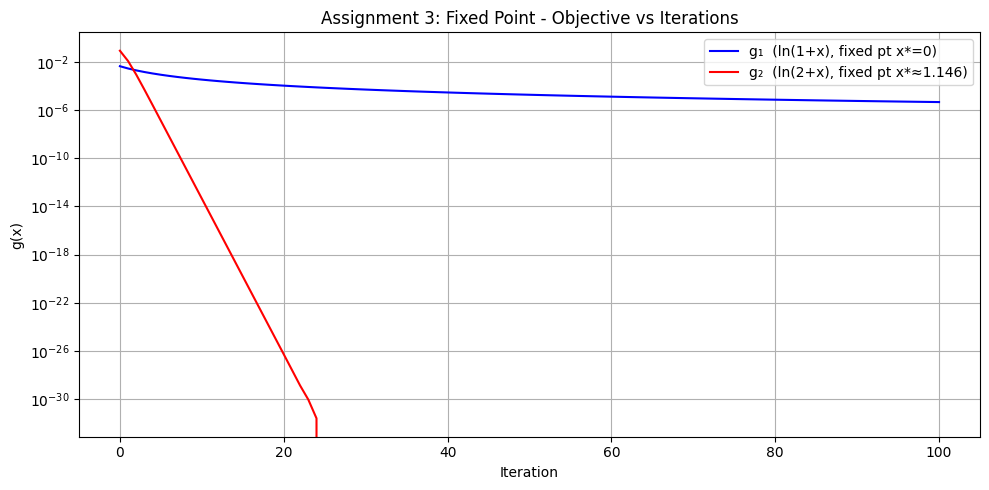

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(hist_f1, 'b-', label='g₁  (ln(1+x), x*=0)')
plt.plot(hist_f2, 'r-', label=f'g₂  (ln(2+x), x*≈{fp2:.3f})')
plt.xlabel('Iteration')
plt.ylabel('g(x)')
plt.title('Assignment 3: Fixed Point - Objective vs Iterations')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.tight_layout()